# Vehicle CO2 Emissions: Segmentation Analysis and Predictive Modeling

Dataset: EPA Fuel Economy Guide (`all_alpha_25.xlsx`)

This project is organized into **two independent parts**, each answering a different question:

- **Part 1 — Segmentation (Clustering):** Which natural groups of vehicles exist based on technical specifications, and how do these groups differ in CO2 output?
- **Part 2 — Prediction (Regression):** Given a vehicle's technical specifications, how much CO2 (g/mile) does it emit?

Both parts share the same cleaned dataset and preprocessing pipeline, but the regression model in Part 2 does **not** depend on the clustering result from Part 1 — clustering is used purely as an exploratory/interpretability tool. Whether adding the cluster label actually helps prediction is tested separately, as an appendix experiment at the end of this notebook.

| Feature                  | Description                                                            |
| ------------------------ | ---------------------------------------------------------------------- |
| **Model**                | Manufacturer and model name of the vehicle.                            |
| **Displ**                | Engine displacement in liters.                                         |
| **Cyl**                  | Number of engine cylinders.                                            |
| **Trans**                | Transmission type and number of gears.                                 |
| **Drive**                | Drive axle configuration (2WD or 4WD).                                 |
| **Fuel**                 | Fuel type used by the vehicle.                                         |
| **Cert Region**          | Vehicle certification region (Federal or California).                  |
| **Stnd**                 | Vehicle emission standard code.                                        |
| **Stnd Description**     | Description of the emission standard.                                  |
| **Underhood ID**         | EPA engine family identification code.                                 |
| **Veh Class**            | EPA vehicle classification.                                            |
| **Air Pollution Score**  | EPA smog rating for air pollutant emissions.                           |
| **City MPG**             | Estimated fuel economy in city driving (miles per gallon).             |
| **Hwy MPG**              | Estimated fuel economy in highway driving (miles per gallon).          |
| **Cmb MPG**               | Estimated combined fuel economy (miles per gallon).                    |
| **Greenhouse Gas Score** | EPA greenhouse gas emission rating.                                    |
| **SmartWay**              | EPA environmental certification label (`Yes`, `Elite`, or `No`).       |
| **Comb CO2**              | Combined tailpipe CO2 emissions (g/mile) — **target variable**.        |

# 1. LOAD DATASET & DATA INSPECTION

## Load dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
df = pd.read_excel("/content/drive/MyDrive/PROJECT/all_alpha_25.xlsx")

In [3]:
df.head(5)

,Model,Displ,Cyl,Trans,Drive,Fuel,Cert Region,Stnd,Stnd Description,Underhood ID,Veh Class,Air Pollution Score,City MPG,Hwy MPG,Cmb MPG,Greenhouse Gas Score,SmartWay,Comb CO2
0,ACURA Integra,1.5,4.0,SCV-7,2WD,Gasoline,CA,L3SULEV30,California LEV-III SULEV30,SHNXV01.54EC,large car,6,30,37,33,6,No,269
1,ACURA Integra,1.5,4.0,SCV-7,2WD,Gasoline,FA,T3B30,Federal Tier 3 Bin 30,SHNXV01.54EC,large car,6,30,37,33,6,No,269
2,ACURA Integra,2.0,4.0,Man-6,2WD,Gasoline,CA,L3ULEV50,California LEV-III ULEV50,SHNXV02.0TDC,large car,5,21,28,24,5,No,371
3,ACURA Integra,2.0,4.0,Man-6,2WD,Gasoline,FA,T3B50,Federal Tier 3 Bin 50,SHNXV02.0TDC,large car,5,21,28,24,5,No,371
4,ACURA Integra A-Spec,1.5,4.0,Man-6,2WD,Gasoline,CA,L3ULEV50,California LEV-III ULEV50,SHNXV01.55DC,large car,5,26,36,30,6,No,293


## Data summary

In [4]:
print("DATA SUMMARY: ")
print("\nData Info: ")
print(df.info(), "\n")
print("\nData Statistics: ")
print(df.describe(), "\n")
print("\nMissing value: ")
print(df.isna().sum(), "\n")
print("\nDuplicate record: ")
print(df.duplicated().sum())

DATA SUMMARY: 

Data Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2492 entries, 0 to 2491
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 2492 non-null   object 
 1   Displ                 1831 non-null   float64
 2   Cyl                   1831 non-null   float64
 3   Trans                 2492 non-null   object 
 4   Drive                 2492 non-null   object 
 5   Fuel                  2492 non-null   object 
 6   Cert Region           2492 non-null   object 
 7   Stnd                  2492 non-null   object 
 8   Stnd Description      2492 non-null   object 
 9   Underhood ID          2492 non-null   object 
 10  Veh Class             2492 non-null   object 
 11  Air Pollution Score   2492 non-null   int64  
 12  City MPG              2492 non-null   object 
 13  Hwy MPG               2492 non-null   object 
 14  Cmb MPG               2492 non-null   object

In [5]:
print("UNIQUE VALUES: \n")
for col in df.select_dtypes(include="object").columns:
  print(col)
  print("="*60)
  print(f"Unique values: {df[col].nunique()}")
  print(df[col].value_counts())
  print("\n")

UNIQUE VALUES: 

Model
Unique values: 880
Model
CHEVROLET Silverado                         32
GMC Sierra                                  30
CHEVROLET Silverado 4WD Mud Terrain Tire    16
MAZDA 3                                     14
GMC Sierra 4WD Mud Terrain Tires            14
                                            ..
LAND ROVER Range Rover SV MHEV               2
LAND ROVER Range Rover Sport MHEV            2
LAND ROVER Range Rover Sport P460 PHEV       2
LAND ROVER Range Rover Sport SVR MHEV        2
LAND ROVER Discovery MHEV                    2
Name: count, Length: 880, dtype: int64


Trans
Unique values: 24
Trans
Auto-1         625
SemiAuto-8     529
Auto-8         158
SemiAuto-10    144
Auto-10        142
Auto-9         128
CVT            112
AMS-7          102
SemiAuto-9      72
AMS-8           72
Man-6           68
SCV-8           62
SCV-6           56
SemiAuto-6      50
Auto-2          38
AMS-6           36
AutoMan-8       34
SCV-1           18
SCV-10          14
Aut

## Comments

**OVERVIEW:**
- The dataset contains **2492 rows** and **18 columns**.
- It includes categorical features such as `Fuel`, `Trans`, `Drive`, `Veh Class`,..., as well as numerical features such as `Displ`, `Cyl`, `Air Pollution Score`, `Greenhouse Gas Score`,...

**MISSING VALUES:**
- The `Displ` and `Cyl` columns both contain **661 missing values**.
- In addition, the minimum value of these two features is **-1**, as shown in the descriptive statistics — this is a placeholder for "not applicable" (mainly electric vehicles), not a real missing value.

**DUPLICATE RECORDS (same vehicle, different certification region):**
- Many rows are identical in every technical column except `Cert Region` / `Stnd` (e.g., the same car tested under Federal vs. California standards). These are administrative duplicates, not distinct vehicles.

**HIGH CARDINALITY:**
- `Model` (vehicle model name) and `Underhood ID` have high cardinality.

**POTENTIAL DATA LEAKAGE:**
- `City MPG`, `Hwy MPG`, and `Cmb MPG` are almost perfectly (inversely) related to the target (`Comb CO2`) and would leak the answer if used as features.
- `Greenhouse Gas Score` and `SmartWay` are EPA-derived ratings computed **from** CO2/pollution scores — they are outputs, not technical specifications, so they leak the target as well (confirmed visually in the EDA section below).

**FEATURE ENGINEERING:**
- `Trans` contains two pieces of information (transmission type + number of gears) and should be split into `Trans_Type` and `Num_Gears`.

**NEXT STEPS (applied together in Section 2):**
1. Drop `Underhood ID`, `Stnd Description`, `Cert Region`, `Stnd`, `City/Hwy/Cmb MPG`, `SmartWay` (kept `Model` only for labeling, not for training).
2. Deduplicate rows that represent the same vehicle under different certification regions.
3. Fix placeholder `-1` values in `Displ`/`Cyl`.
4. Split `Trans` into `Trans_Type` + `Num_Gears`.
5. Fix the `Comb CO2` "x/y" notation found in Flex-Fuel (Ethanol/Gas) vehicles.
6. Remove `Greenhouse Gas Score` and `Air Pollution Score` after confirming leakage/non-technical nature in EDA.

# 2. DATA CLEANING

In [6]:
# Drop columns that are administrative codes, redundant descriptions, or would
# leak the target (MPG columns), plus SmartWay (derived rating, see EDA comments below)
df = df.drop(["Underhood ID", "Stnd Description", "City MPG", "Hwy MPG", "Cmb MPG", "Cert Region", "Stnd", "SmartWay"], axis=1)

In [7]:
# Deduplicate: Cert Region/Stnd (already dropped above) were the only columns
# that differed between rows describing the same physical vehicle, so a plain
# drop_duplicates on all remaining columns now correctly collapses those rows.
print("Before dedupe:", len(df))
df = df.drop_duplicates(subset=df.columns, keep="first")
df.reset_index(drop=True, inplace=True)
print("After dedupe:", len(df))

Before dedupe: 2492
After dedupe: 1217


In [8]:
# Displ/Cyl: -1 is a placeholder (mostly electric vehicles) -> convert to NaN,
# then fill with 0. Fuel type (one-hot encoded later) already flags these
# vehicles as "Electricity", so a separate is_electric flag is not needed.
df["Displ"] = df["Displ"].replace(-1, np.nan).fillna(0)
df["Cyl"] = df["Cyl"].replace(-1, np.nan).fillna(0)

In [9]:
# Split "Trans" (e.g. "Auto-6", "SCV-7") into transmission type + number of gears.
# CVT/SCV-type transmissions have no fixed gear count -> Num_Gears = 0 is a real
# value here ("not applicable"), distinct in meaning from the Displ/Cyl 0 above.
df[["Trans_Type", "Num_Gears"]] = df["Trans"].str.extract(r"([A-Za-z]+)-?(\d+)?")
df["Num_Gears"] = pd.to_numeric(df["Num_Gears"]).fillna(0)
df.drop(columns="Trans", inplace=True)

df.head()

,Model,Displ,Cyl,Drive,Fuel,Veh Class,Air Pollution Score,Greenhouse Gas Score,Comb CO2,Trans_Type,Num_Gears
0,ACURA Integra,1.5,4.0,2WD,Gasoline,large car,6,6,269,SCV,7.0
1,ACURA Integra,2.0,4.0,2WD,Gasoline,large car,5,5,371,Man,6.0
2,ACURA Integra A-Spec,1.5,4.0,2WD,Gasoline,large car,5,6,293,Man,6.0
3,ACURA Integra A-Spec,1.5,4.0,2WD,Gasoline,large car,6,6,277,SCV,7.0
4,ACURA MDX,3.5,6.0,2WD,Gasoline,small SUV,4,5,411,SemiAuto,10.0


In [10]:
# Sanity check: confirm -1 placeholders are gone and no unexpected NaNs remain
df.describe()

,Displ,Cyl,Air Pollution Score,Greenhouse Gas Score,Num_Gears
count,1217.000000,1217.000000,1217.000000,1217.000000,1217.000000
mean,2.223254,4.010682,6.252260,6.173377,5.939195
std,1.641864,2.786371,2.446056,2.593707,3.484871
min,0.000000,0.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,4.000000,4.000000,1.000000
50%,2.400000,4.000000,6.000000,5.000000,8.000000
75%,3.000000,6.000000,10.000000,10.000000,8.000000
max,8.000000,16.000000,10.000000,10.000000,10.000000


In [11]:
# Comb CO2 also uses "x/y" notation for Flex-Fuel (Ethanol/Gas) vehicles
# (same pattern as the MPG columns) -> needs to be split before converting to numeric.
print("Rows with 'x/y' CO2 notation:", df["Comb CO2"].astype(str).str.contains("/").sum())

# Split each Flex-Fuel row into two separate rows: one for Gasoline, one for Ethanol,
# each carrying its own correct CO2 value.
ffv_mask = df["Fuel"] == "Ethanol/Gas"
co2_split = df.loc[ffv_mask, "Comb CO2"].str.split("/", expand=True)

gas_df = df.loc[ffv_mask].copy()
ethanol_df = df.loc[ffv_mask].copy()
gas_df["Fuel"] = "Gasoline"
ethanol_df["Fuel"] = "Ethanol"
gas_df["Comb CO2"] = co2_split[0]
ethanol_df["Comb CO2"] = co2_split[1]

df = df.loc[~ffv_mask].copy()
df = pd.concat([df, gas_df, ethanol_df], ignore_index=True)
df["Comb CO2"] = pd.to_numeric(df["Comb CO2"])

Rows with 'x/y' CO2 notation: 8


# 3. EDA

## Numerical feature analysis

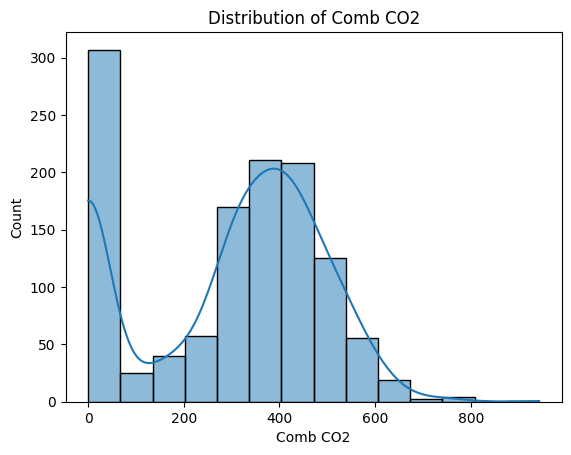

In [12]:
# Target distribution
sns.histplot(df["Comb CO2"], kde=True)
plt.title("Distribution of Comb CO2")
plt.show()

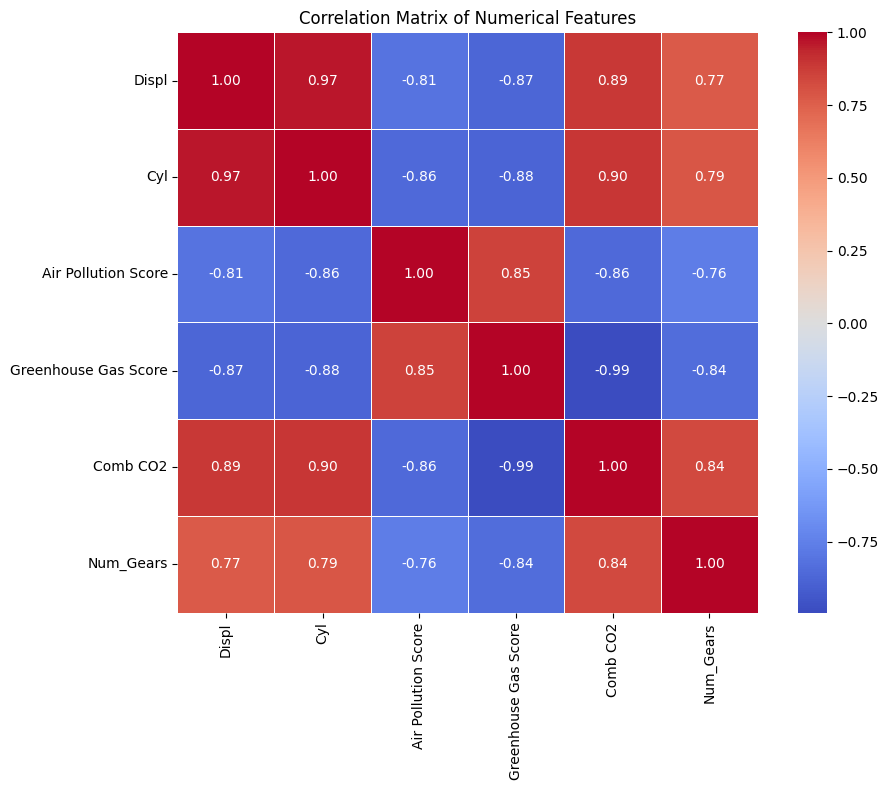

In [13]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
corr = numeric_df.corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5, cbar=True)
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

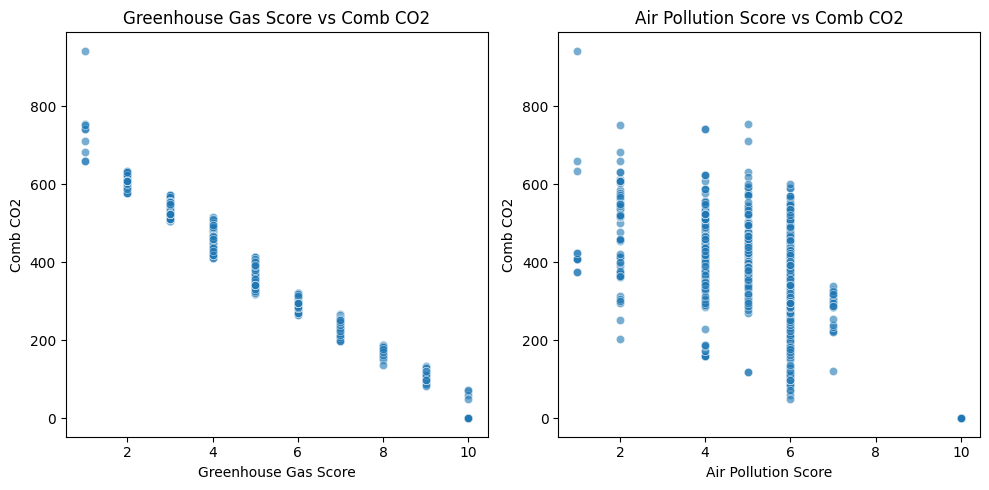

In [14]:
# Checking whether Greenhouse Gas Score / Air Pollution Score leak the target
leakage_features = ["Greenhouse Gas Score", "Air Pollution Score"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, feature in zip(axes, leakage_features):
    sns.scatterplot(data=df, x=feature, y="Comb CO2", alpha=0.6, ax=ax)
    ax.set_title(f"{feature} vs Comb CO2")

plt.tight_layout()
plt.show()

**Observations:**
- `Greenhouse Gas Score` shows an almost perfect inverse linear relationship with `Comb CO2` → confirms it is a direct, EPA-computed transformation of the target → **remove (data leakage)**.
- `Air Pollution Score` shows a weak, scattered relationship (same score maps to a wide range of CO2 values) → not leakage in a statistical sense, but it is an *evaluation rating* for other pollutants (NOx, CO, etc.), not a *technical specification* of the vehicle → **remove (not a structural feature, per problem framing)**.
- `SmartWay` (already dropped in Section 2) is an EPA label computed from thresholds on both scores above, so it inherits the same leakage indirectly.

## Categorical feature analysis

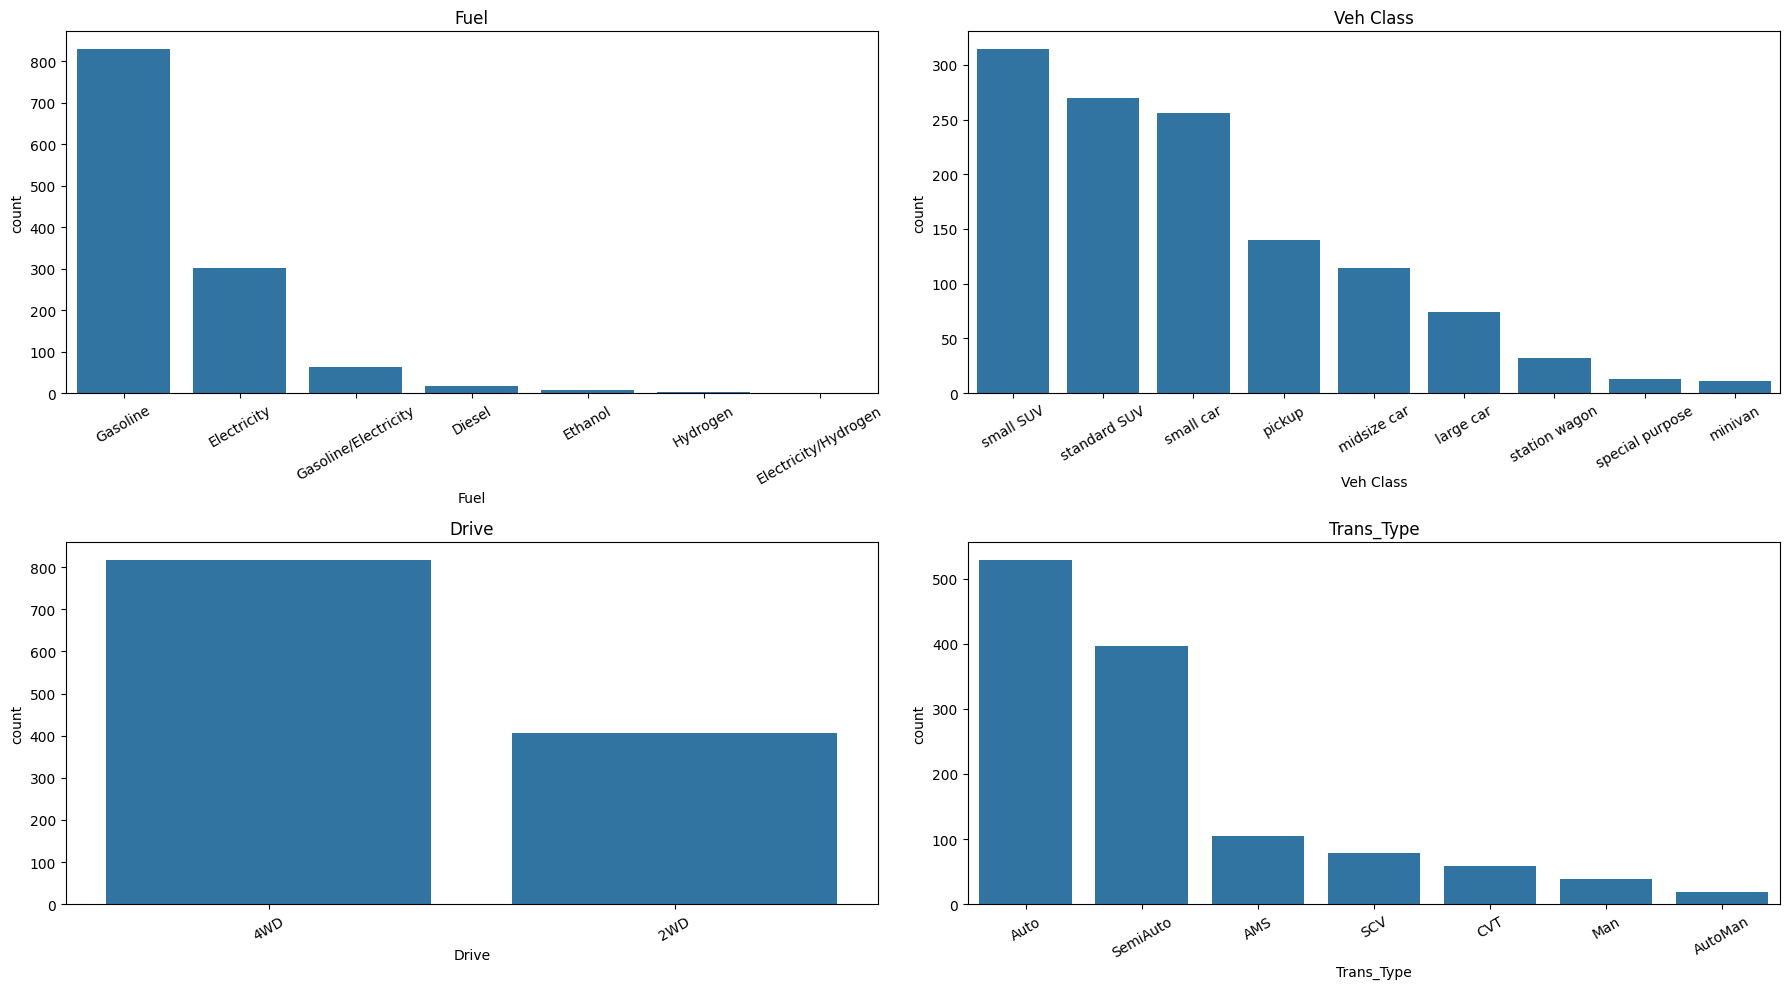

In [15]:
categorical_features = ["Fuel", "Veh Class", "Drive", "Trans_Type"]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()
for ax, feature in zip(axes, categorical_features):
    sns.countplot(data=df, x=feature, order=df[feature].value_counts().index, ax=ax)
    ax.set_title(feature)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

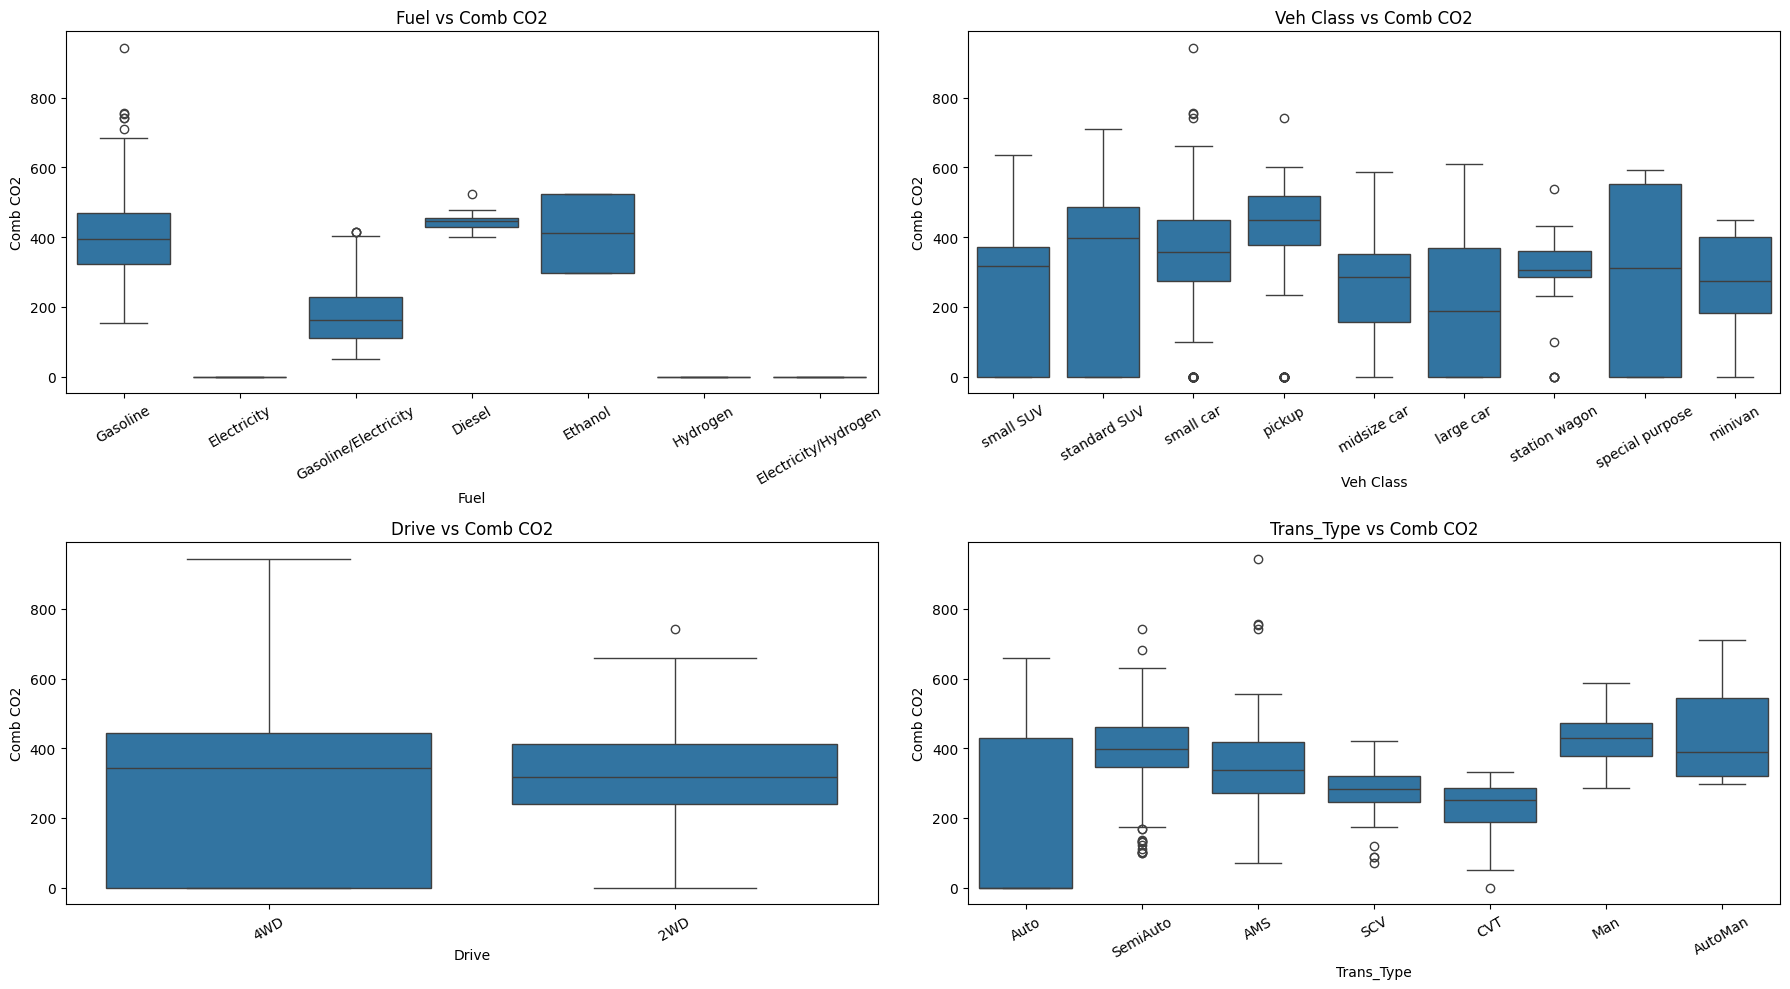

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()
for ax, feature in zip(axes, categorical_features):
    sns.boxplot(data=df, x=feature, y="Comb CO2", order=df[feature].value_counts().index, ax=ax)
    ax.set_title(f"{feature} vs Comb CO2")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [17]:
# Apply conclusions from the leakage analysis above
df = df.drop(["Greenhouse Gas Score", "Air Pollution Score"], axis=1)
df.head()

,Model,Displ,Cyl,Drive,Fuel,Veh Class,Comb CO2,Trans_Type,Num_Gears
0,ACURA Integra,1.5,4.0,2WD,Gasoline,large car,269,SCV,7.0
1,ACURA Integra,2.0,4.0,2WD,Gasoline,large car,371,Man,6.0
2,ACURA Integra A-Spec,1.5,4.0,2WD,Gasoline,large car,293,Man,6.0
3,ACURA Integra A-Spec,1.5,4.0,2WD,Gasoline,large car,277,SCV,7.0
4,ACURA MDX,3.5,6.0,2WD,Gasoline,small SUV,411,SemiAuto,10.0


# 4. FEATURE PREPROCESSING

Shared by both Part 1 (Clustering) and Part 2 (Regression).

In [18]:
# Model is kept only for labeling/display, never used as a training feature
X = df.drop(["Model", "Comb CO2"], axis=1)
y = df["Comb CO2"]

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ["Trans_Type", "Drive", "Fuel", "Veh Class"]
numeric_cols = ["Displ", "Cyl", "Num_Gears"]

# Fit only on train to avoid leaking test-set categories into the encoder;
# handle_unknown="ignore" protects against categories that appear only in test.
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

encoded_col_names = encoder.get_feature_names_out(categorical_cols)
X_train_cat_df = pd.DataFrame(X_train_cat, columns=encoded_col_names, index=X_train.index)
X_test_cat_df = pd.DataFrame(X_test_cat, columns=encoded_col_names, index=X_test.index)

X_train_final = pd.concat([X_train[numeric_cols], X_train_cat_df], axis=1)
X_test_final = pd.concat([X_test[numeric_cols], X_test_cat_df], axis=1)

print(X_train_final.shape, X_test_final.shape)

(980, 28) (245, 28)


In [21]:
from sklearn.preprocessing import StandardScaler

# Fit only on train, then transform both -> no test-set information leaks into
# the scaling parameters. One-hot columns are left unscaled (already 0/1).
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_final[numeric_cols])
X_test_num_scaled = scaler.transform(X_test_final[numeric_cols])

X_train_num_scaled_df = pd.DataFrame(X_train_num_scaled, columns=numeric_cols, index=X_train_final.index)
X_test_num_scaled_df = pd.DataFrame(X_test_num_scaled, columns=numeric_cols, index=X_test_final.index)

X_train_scaled = pd.concat([X_train_num_scaled_df, X_train_cat_df], axis=1)
X_test_scaled = pd.concat([X_test_num_scaled_df, X_test_cat_df], axis=1)

print(X_train_scaled.shape, X_test_scaled.shape)

(980, 28) (245, 28)


# PART 1 — VEHICLE SEGMENTATION (CLUSTERING)

**Goal:** group vehicles by technical profile (`Displ`, `Cyl`, `Num_Gears`, `Drive`, `Fuel`, `Veh Class`) and describe how CO2 output varies across the resulting groups.

Note: `Comb CO2` is **not** used to form the clusters — it is only used afterward, to interpret what each cluster represents.

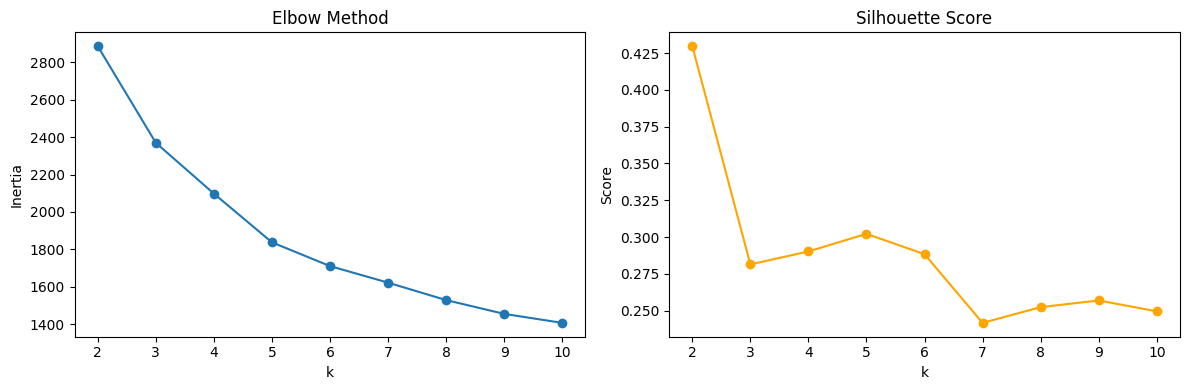

In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia_list, silhouette_list = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_scaled)
    inertia_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(X_train_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_range, inertia_list, marker="o")
axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(k_range, silhouette_list, marker="o", color="orange")
axes[1].set_title("Silhouette Score"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Score")
plt.tight_layout()
plt.show()

**k selection:** k=2 has the highest silhouette score, but it is too coarse to be useful for segmentation. k=5 is chosen instead — it sits at a clear elbow in the inertia curve and is a local peak in silhouette score among k≥3, giving a good balance between cluster quality and useful granularity.

In [23]:
best_k = 5

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
train_cluster_labels = kmeans.fit_predict(X_train_scaled)          # fit only on train
test_cluster_labels = kmeans.predict(X_test_scaled)                 # predict only, no re-fit on test

# Kept in separate *_clustered variables so Part 2's main regression features
# (X_train_scaled / X_test_scaled) stay untouched by the clustering step.
X_train_clustered = X_train.copy()
X_test_clustered = X_test.copy()
X_train_clustered["cluster"] = train_cluster_labels
X_test_clustered["cluster"] = test_cluster_labels

In [24]:
# Cluster profile: average technical specs + mean CO2 per cluster
cluster_profile = X_train_clustered.groupby("cluster")[["Displ", "Cyl", "Num_Gears"]].mean()
cluster_profile["Comb CO2 (mean)"] = y_train.groupby(train_cluster_labels).mean()
cluster_profile["count"] = X_train_clustered.groupby("cluster").size()
print(cluster_profile)

            Displ       Cyl  Num_Gears  Comb CO2 (mean)  count
cluster                                                       
0        1.948148  3.907407   0.185185       245.111111     54
1        2.594199  4.784530   8.038674       372.773481    362
2        0.000000  0.000000   1.061983         0.000000    242
3        2.519072  4.675258   7.783505       358.623711    194
4        5.000000  8.375000   8.781250       519.531250    128


In [25]:
# Categorical composition per cluster (helps explain clusters with similar
# numeric profiles, e.g. Cluster 1 vs 3 below)
for col in ["Fuel", "Drive", "Veh Class", "Trans_Type"]:
    print(f"\n{col} by cluster:")
    print(pd.crosstab(X_train_clustered["cluster"], X_train[col], normalize="index").round(2))


Fuel by cluster:
Fuel     Diesel  Electricity  Electricity/Hydrogen  Ethanol  Gasoline  \
cluster                                                                 
0          0.00         0.00                   0.0     0.02      0.91   
1          0.02         0.00                   0.0     0.00      0.90   
2          0.00         0.99                   0.0     0.00      0.00   
3          0.02         0.00                   0.0     0.01      0.96   
4          0.00         0.00                   0.0     0.03      0.85   

Fuel     Gasoline/Electricity  Hydrogen  
cluster                                  
0                        0.07      0.00  
1                        0.08      0.00  
2                        0.00      0.01  
3                        0.01      0.00  
4                        0.12      0.00  

Drive by cluster:
Drive     2WD   4WD
cluster            
0        0.69  0.31
1        0.00  1.00
2        0.26  0.74
3        1.00  0.00
4        0.22  0.78

Veh Class by clu

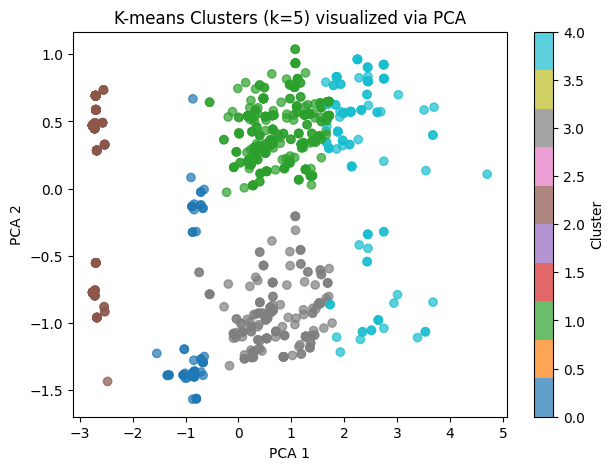

In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=train_cluster_labels, cmap="tab10", alpha=0.7)
plt.xlabel("PCA 1"); plt.ylabel("PCA 2")
plt.title(f"K-means Clusters (k={best_k}) visualized via PCA")
plt.colorbar(scatter, label="Cluster")
plt.show()

| Cluster | Cluster Name | Main Characteristics |
|:------:|-------------------------------|--------------------------------------------------------------------------------------------------------------------------------|
| **0** | Compact CVT Vehicles | Small engine displacement, predominantly CVT transmission (~81%), relatively low CO2 emissions, mainly fuel-efficient compact vehicles. |
| **1** | 4WD Utility Vehicles | Medium engine displacement, exclusively 4WD, primarily SUVs and pickup trucks, moderate to high CO2 emissions. |
| **2** | Zero-Emission Vehicles | ~99% electric vehicles with zero tailpipe CO2 emissions, the cleanest segment. |
| **3** | Compact 2WD Vehicles | Medium engine displacement, exclusively 2WD, mainly compact passenger cars, relatively low to moderate CO2 emissions. |
| **4** | Large-Engine High-Emission Vehicles | Largest average displacement (~ 5.0L) and cylinder count (~ 8.4), highest CO2 emissions among all clusters. |

**Note on Cluster 1 vs 3:** their numeric profiles (Displ, Cyl, Num_Gears) are nearly identical; the crosstab above shows they are actually separated by `Drive` (100% 4WD vs 100% 2WD), which explains the moderate CO2 gap between them (372.8 vs 358.6 g/mile) — heavier 4WD drivetrains emit more CO2 even at similar engine size.

**Conclusion — Part 1:** five technically meaningful vehicle segments were identified, ranging from Zero-Emission to High-Emission, driven mainly by `Displ`/`Cyl` and secondarily by `Drive`. This answers the segmentation question independently of the prediction task in Part 2.

# PART 2 — CO2 EMISSION PREDICTION (REGRESSION)

**Goal:** predict the exact `Comb CO2` value (g/mile) from technical specifications. The main model uses only the raw preprocessed features (`X_train_scaled` / `X_test_scaled`) — **no cluster label**. Whether the Part 1 cluster label adds any predictive value is tested separately in the Appendix.

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name} -> RMSE: {rmse:.2f} | MAE: {mae:.2f} | R2: {r2:.4f}")
    return {"RMSE": rmse, "MAE": mae, "R2": r2}

lr_model = LinearRegression().fit(X_train_scaled, y_train)
rf_model = RandomForestRegressor(random_state=42, n_estimators=300).fit(X_train_scaled, y_train)

print("=== Linear Regression (baseline) ===")
res_lr = evaluate(y_test, lr_model.predict(X_test_scaled), "Linear Regression")
print("\n=== Random Forest ===")
res_rf = evaluate(y_test, rf_model.predict(X_test_scaled), "Random Forest")

=== Linear Regression (baseline) ===
Linear Regression -> RMSE: 50.00 | MAE: 36.09 | R2: 0.9353

=== Random Forest ===
Random Forest -> RMSE: 36.73 | MAE: 22.10 | R2: 0.9651


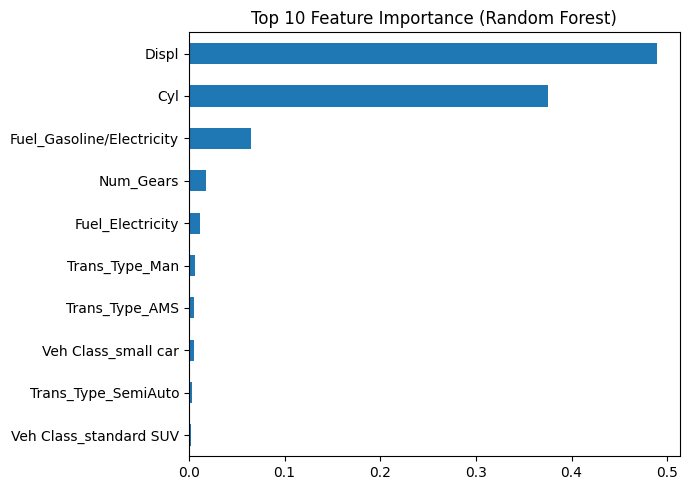

In [28]:
# Feature importance for the stronger model (Random Forest)
importances = pd.Series(rf_model.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 5))
importances.head(10).plot(kind="barh")
plt.title("Top 10 Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Model comparison:**

| Model | RMSE | MAE | R2 |
|---|---|---|---|
| Linear Regression | 50.00 | 36.09 | 0.9353 |
| Random Forest | 36.73 | 22.10 | 0.9651 |

**Selected model: Random Forest.** RMSE is ~26% lower than Linear Regression, indicating Random Forest captures non-linear relationships and feature interactions — e.g., the effect of `Displ` on CO2 differs between 2WD and 4WD vehicles — that Linear Regression, as a purely additive model, cannot represent. Linear Regression is kept as an interpretable baseline: its coefficients give a simple, direct answer to "how much does CO2 change per unit of displacement," which is harder to extract from a Random Forest without extra tools (e.g., SHAP).

In [38]:
# Attach vehicle model names back to the test-set predictions.
# df.loc[X_test.index, "Model"] works because X_test/y_test were split from df
# before dropping "Model", so the original row index is preserved throughout.
results_df = pd.DataFrame({
    "Model": df.loc[X_test.index, "Model"].values,
    "Fuel": X_test["Fuel"].values,
    "Actual_CO2": y_test.values,
    "Predicted_CO2": rf_model.predict(X_test_scaled).round(1),
})
results_df["Error"] = (results_df["Predicted_CO2"] - results_df["Actual_CO2"]).round(1)
results_df["Abs_Error"] = results_df["Error"].abs()
results_df = results_df.sort_values("Abs_Error").reset_index(drop=True)

# Xác định ngưỡng phân vị từ tập train (Low/Moderate/High)
p33, p66 = y_train.quantile([0.33, 0.66])

def get_level(co2):
    if co2 == 0:
        return "Zero-Emission"
    elif co2 < p33:
        return "Low"
    elif co2 < p66:
        return "Moderate"
    else:
        return "High"

results_df["Predicted_Emission_Level"] = results_df["Predicted_CO2"].apply(get_level)

results_df

,Model,Fuel,Actual_CO2,Predicted_CO2,Error,Abs_Error,Predicted_Emission_Level
0,LUCID Gravity GT w/21F22R wheels (2R),Electricity,0,0.0,0.0,0.0,Zero-Emission
1,VINFAST VF 8 Plus,Electricity,0,0.0,0.0,0.0,Zero-Emission
2,VOLVO EX30 Twin Performance (20 Inch Wheels),Electricity,0,0.0,0.0,0.0,Zero-Emission
3,"BMW i4 eDrive40 Gran Coupe (18"" Wheels)",Electricity,0,0.0,0.0,0.0,Zero-Emission
4,AUDI Q8 e-tron quattro,Electricity,0,0.0,0.0,0.0,Zero-Emission
...,...,...,...,...,...,...,...
240,FORD F150 HEV,Gasoline,386,502.5,116.5,116.5,High
241,RAM 1500 RHO,Gasoline,602,483.6,-118.4,118.4,High
242,MAZDA 3,Gasoline,296,415.7,119.7,119.7,High
243,FORD Escape PHEV,Gasoline/Electricity,222,68.7,-153.3,153.3,Low


In [39]:
# Kiểm tra sai số trung bình theo từng loại Fuel
results_df.groupby("Fuel")["Abs_Error"].agg(["mean", "count"]).sort_values("mean", ascending=False)

,mean,count
Fuel,,
Gasoline/Electricity,65.692308,13
Gasoline,27.724540,163
Ethanol,7.600000,1
Diesel,5.760000,5
Hydrogen,4.900000,1
Electricity,0.000000,62


In [41]:
# Quick look at the best and worst predictions
print("Top 70 most accurate predictions:")
display(results_df.head(70))

print("\nTop 10 largest prediction errors:")
display(results_df.sort_values("Abs_Error", ascending=False).head(10))

Top 70 most accurate predictions:


,Model,Fuel,Actual_CO2,Predicted_CO2,Error,Abs_Error,Predicted_Emission_Level
0,LUCID Gravity GT w/21F22R wheels (2R),Electricity,0,0.0,0.0,0.0,Zero-Emission
1,VINFAST VF 8 Plus,Electricity,0,0.0,0.0,0.0,Zero-Emission
2,VOLVO EX30 Twin Performance (20 Inch Wheels),Electricity,0,0.0,0.0,0.0,Zero-Emission
3,"BMW i4 eDrive40 Gran Coupe (18"" Wheels)",Electricity,0,0.0,0.0,0.0,Zero-Emission
4,AUDI Q8 e-tron quattro,Electricity,0,0.0,0.0,0.0,Zero-Emission
...,...,...,...,...,...,...,...
65,GMC Yukon,Gasoline,530,530.5,0.5,0.5,High
66,CHEVROLET Silverado 4WD Mud Terrain Tire,Diesel,456,455.2,-0.8,0.8,High
67,TOYOTA Tundra,Gasoline,460,459.1,-0.9,0.9,High
68,ROLLS-ROYCE Phantom Extended,Gasoline,609,608.1,-0.9,0.9,High



Top 10 largest prediction errors:


,Model,Fuel,Actual_CO2,Predicted_CO2,Error,Abs_Error,Predicted_Emission_Level
244,MERCEDES-BENZ AMG GLC 63 S E Performance,Gasoline/Electricity,379,187.3,-191.7,191.7,Low
243,FORD Escape PHEV,Gasoline/Electricity,222,68.7,-153.3,153.3,Low
242,MAZDA 3,Gasoline,296,415.7,119.7,119.7,High
241,RAM 1500 RHO,Gasoline,602,483.6,-118.4,118.4,High
240,FORD F150 HEV,Gasoline,386,502.5,116.5,116.5,High
239,BMW X6 xDrive40i,Gasoline,359,460.4,101.4,101.4,High
238,MERCEDES-BENZ GLE 450e 4MATIC,Gasoline/Electricity,99,197.5,98.5,98.5,Low
237,TOYOTA GR Corolla,Gasoline,395,299.6,-95.4,95.4,Moderate
235,FERRARI 296 GTB,Gasoline/Electricity,398,303.5,-94.5,94.5,Moderate
236,CHRYSLER Pacifica Hybrid,Gasoline/Electricity,119,213.5,94.5,94.5,Low


**CROSS-VALIDATION AND HYPERPARAMETERS TUNING**

In [36]:
from sklearn.model_selection import cross_validate, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    RandomForestRegressor(random_state=42, n_estimators=300),
    X_train_scaled, y_train,
    cv=kf,
    scoring=["neg_root_mean_squared_error", "r2"]
)

print("RMSE per fold:", -cv_results["test_neg_root_mean_squared_error"])
print("RMSE average:", -cv_results["test_neg_root_mean_squared_error"].mean())
print("RMSE std deviation:", cv_results["test_neg_root_mean_squared_error"].std())
print("\nR² per fold:", cv_results["test_r2"])
print("R² average:", cv_results["test_r2"].mean())

RMSE per fold: [38.64266998 38.4734593  31.62125004 40.16102999 42.12409267]
RMSE average: 38.20450039733616
RMSE std deviation: 3.5438602795331655

R² per fold: [0.96061223 0.95442262 0.97375904 0.95861301 0.95947682]
R² average: 0.9613767445151098


5-fold cross-validation confirmed the Random Forest model's performance is stable across different data splits (mean RMSE = 38.20 ± 3.54, mean R² = 0.961 ± 0.007), closely matching the hold-out test result (RMSE = 36.73, R² = 0.9651). Given this stability, hyperparameter tuning was not pursued further

**SAVE MODEL**

In [37]:
import joblib

joblib.dump(rf_model, "rf_model.pkl")   # dùng bản gốc, không phải best_rf_model
joblib.dump(encoder, "encoder.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(kmeans, "kmeans.pkl")
joblib.dump(categorical_cols, "categorical_cols.pkl")
joblib.dump(numeric_cols, "numeric_cols.pkl")

unique_values = {col: sorted(df[col].dropna().unique().tolist()) for col in categorical_cols}
joblib.dump(unique_values, "unique_values.pkl")

['unique_values.pkl']

# APPENDIX — Additional Experiment: Does the Part 1 cluster label improve regression?

This is a secondary question, kept separate from the main Part 2 result above. It tests whether adding the `cluster` label from Part 1 as an extra feature improves prediction — motivated by the "Clustering-Based Regression" idea explored earlier in this project.

In [35]:
# Add the Part 1 cluster label (already fit on train only, predicted on test only)
# as an extra one-hot feature on top of the same base features used in Part 2.
X_train_with_cluster = pd.get_dummies(
    X_train_scaled.assign(cluster=train_cluster_labels), columns=["cluster"], prefix="cluster"
)
X_test_with_cluster = pd.get_dummies(
    X_test_scaled.assign(cluster=test_cluster_labels), columns=["cluster"], prefix="cluster"
)
# Align columns in case a cluster id is missing from one of the splits
X_test_with_cluster = X_test_with_cluster.reindex(columns=X_train_with_cluster.columns, fill_value=0)

lr_cluster = LinearRegression().fit(X_train_with_cluster, y_train)
rf_cluster = RandomForestRegressor(random_state=42, n_estimators=300).fit(X_train_with_cluster, y_train)

print("=== Linear Regression (+ cluster) ===")
res_lr_c = evaluate(y_test, lr_cluster.predict(X_test_with_cluster), "Linear Regression + cluster")
print("\n=== Random Forest (+ cluster) ===")
res_rf_c = evaluate(y_test, rf_cluster.predict(X_test_with_cluster), "Random Forest + cluster")

=== Linear Regression (+ cluster) ===
Linear Regression + cluster -> RMSE: 50.04 | MAE: 35.66 | R2: 0.9352

=== Random Forest (+ cluster) ===
Random Forest + cluster -> RMSE: 37.55 | MAE: 22.30 | R2: 0.9635


**Comparison:**

| Model | RMSE | MAE | R2 |
|---|---|---|---|
| Linear Regression (no cluster) | 50.00 | 36.09 | 0.9353 |
| Linear Regression (+ cluster) | 50.04 | 35.66 | 0.9352 |
| Random Forest (no cluster) | **36.73** | **22.10** | **0.9651** |
| Random Forest (+ cluster) | 37.55 | 22.30 | 0.9635 |

**Finding: adding the cluster label does not improve, and slightly hurts, Random Forest performance; it has no meaningful effect on Linear Regression.** This is because the cluster label is derived entirely from features (`Displ`, `Cyl`, `Drive`, `Fuel`, `Veh Class`) that are already available to both models. Random Forest builds its own splits directly on these raw features and effectively learns the same (or finer) group boundaries on its own, so the cluster label only adds redundant, lower-resolution information — and a bit of extra dimensionality — without new signal. Linear Regression, in turn, already captures the roughly linear CO2 trend across the technical features, so the additional categorical cluster variable contributes little.

**Takeaway:** clustering remains valuable as an interpretability/segmentation tool (Part 1), but is not necessary — and mildly counterproductive for tree-based models — as an input feature for CO2 prediction (Part 2).

# OVERALL CONCLUSION

- **Part 1 (Segmentation):** K-means (k=5) identified five technically coherent vehicle groups, from Zero-Emission to High-Emission, driven primarily by engine displacement/cylinder count and secondarily by drivetrain type.
- **Part 2 (Prediction):** Random Forest predicts `Comb CO2` with RMSE ≈ 36.7 g/mile and R² ≈ 0.965, meaningfully outperforming the Linear Regression baseline by capturing non-linear feature interactions.
- **Appendix finding:** combining the two — using cluster labels as a regression feature — does not improve prediction, since tree-based models already recover equivalent structure from the raw features. This was tested empirically rather than assumed, and is reported as a negative result / design insight rather than as a failure.